In [1]:
pip install energyflow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [581]:
import numpy as np
import energyflow as ef
import torch

import warnings
warnings.filterwarnings('ignore')

print(np.__version__)


1.26.4


In [583]:
n_events=1000
T=15
n_diff=20   

In [587]:
# Code to generate EFP's for the clean dataset (x_0) 

p_space='pSARGE_N10_xi20_100k.pt'   

p_space_events_full=torch.load(p_space)
p_space_events=p_space_events_full[:n_events]


energies=torch.linalg.norm(p_space_events, dim=2, keepdim=True)   # calulates the energies for each particle in the event 

p_space_events=torch.cat([energies, p_space_events],dim=2).numpy() # add the energies to momenta to make it a four vector

# get all EFPs with d<=5
efpset = ef.EFPSet('d<=5', measure='ee', beta=2, normed=True, verbose=True)  

#compute their values on our events. 
results = np.asarray([efpset.compute(event) for event in p_space_events])

results.shape  


Originally Available EFPs:
  Prime: 23691
  Composite: 21540
  Total:  45231
Current Stored EFPs:
  Prime: 54
  Composite: 48
  Total:  102


(1000, 102)

In [589]:
#from petmodel.qspace  import qs_to_ps

#q_space='qSARGE_N10_xi20_100k.pt'

#q_space_events_full=torch.load(q_space)
#q_space_events=q_space_events_full[:1000]

#qs_to_ps(q_space_events[0:10],energy=1.0)


#torch.save(P_denoised.cpu(), OUTPUT_PATH)
#np.save(OUTPUT_PATH.replace('.pt', '.npy'), P_denoised.cpu().numpy())
#print(f'Saved: {OUTPUT_PATH}')


Q_denoised1=torch.load('denoised_checkpoint_new.pt')
Q1=Q_denoised1['Q_denoised']

Q1[Q1==0]=np.nan

Q_denoised2=torch.load('denoised_checkpoint.pt')
Q2=Q_denoised2['Q_denoised']

Q_new=torch.cat([Q1[:5],Q2],axis=0)
Q_new.shape

torch.Size([15, 20, 1000, 10, 3])

In [591]:
# Generate events in p_space from our denoised q_space data 

from petmodel.qspace  import qs_to_ps


P_denoised=torch.zeros(T,n_diff,1000,10,3) 

for i in range(T):
    for j in range(n_diff):
        P_denoised[i][j] = qs_to_ps(Q_new[i][j], energy=1.0)
        #print('P-space output shape:', P_denoised.shape)

P_denoised_energies=torch.linalg.norm(P_denoised, dim=4, keepdim=True)

P_denoised_events=torch.cat([P_denoised_energies,P_denoised],dim=4).numpy()

P_denoised_events.shape



(15, 20, 1000, 10, 4)

In [593]:
# Generate EFP data \hat{x}_0 for events in the denoised data. 

denoised_efp_results=np.zeros((T,n_diff,1000,results.shape[1])) 

for i in range(T):
    for j in range(n_diff):
        for k, event in enumerate(P_denoised_events[i, j]):
            
            if not np.isnan(event).any():
                denoised_efp_results[i][j][k] = np.asarray(efpset.compute(event)) 
            else:
                # If an event contains any nan values, set that event to all nan values in the efp space.
                denoised_efp_results[i][j][k] = np.full(results.shape[1],np.nan) 

#np.save('denoised_efp_data_4.npy',denoised_efp_results)

In [51]:
# Code to check nan frac for events for each time slice

denoised_efp_results= np.load("denoised_efp_data.npy")
denoised_efp_results.shape 

nan_frac = np.isnan(denoised_efp_results).any(axis=-1).mean(axis=(1,2))
for i in range(T):
    print(f'T_STAR={i}  NaN fraction: {nan_frac[i]:.3f}')


T_STAR=0  NaN fraction: 0.325
T_STAR=1  NaN fraction: 0.329
T_STAR=2  NaN fraction: 0.335
T_STAR=3  NaN fraction: 0.342
T_STAR=4  NaN fraction: 0.348
T_STAR=5  NaN fraction: 0.358
T_STAR=6  NaN fraction: 0.368
T_STAR=7  NaN fraction: 0.386
T_STAR=8  NaN fraction: 0.405
T_STAR=9  NaN fraction: 0.458


In [595]:

# Here we calculate the connected correlator for our data. 

results_new = np.tile(
    results[np.newaxis, np.newaxis, :, :],   # (1, 1, 1000, n_efp)   #Create a new array results_new to make n_diff copies of results for each time slice
    (T, n_diff, 1, 1)        # tile to (10, 20, 1000, n_efp)
)
print('results_new shape:', results_new.shape)  # (10, 20, 1000, n_efp)

diff= np.abs(results_new - denoised_efp_results)   # This is the absolute distance between x_0 and \hat{x}_0 which we will use in our correlation. 

device = torch.device('mps')


correlator = np.einsum('...i,...j->...ij', diff, diff)                                                 # correlator
diff_avg= np.nanmean(diff,axis=1)                                                                      # avg over the diffusion trajectories for sigma
correlator_avg = np.nanmean(correlator, axis=1) - np.einsum('...i,...j->...ij', diff_avg, diff_avg)    # connected correlator
corr_final=np.nanmean(correlator_avg,axis=1)                                                           # avg over the events 



results_new shape: (15, 20, 1000, 102)


In [ ]:
#corr_final = torch.zeros((T, results.shape[1], results.shape[1]), dtype=torch.float32, device=device)

#for t in range(T):
#    diff_t = torch.tensor(diff[t].reshape(-1, 3389), dtype=torch.float32, device=device)  # collapse n_diff and n_events into one axis for each time slice
#    diff_avg = torch.nanmean(diff_t, dim=0)             # Calculate mean over diffusion trajectories and events 
#    diff_clean = torch.nan_to_num(diff_t, nan=0.0)      
#    valid_counts = (~torch.isnan(diff_t)).sum(dim=0)
    
#    xixj = (diff_clean.T @ diff_clean) / valid_counts[None, :]   # E(\sigma_i \sigma_j)
#    corr_final[t] = xixj - torch.outer(diff_avg, diff_avg)       #

In [597]:
#corr_final=corr_final.cpu().numpy()

diag_sum = np.trace(corr_final, axis1=1, axis2=2)        # trace of the correlator
total_sum = corr_final.sum(axis=(1, 2))                  # Correlator sum
result_new = total_sum / diag_sum                            # Susceptibility

result_new

array([28.95522796, 28.93929454, 28.67484484, 28.48113247, 28.47460288,
       28.38335588, 28.07529426, 27.93056547, 27.90129731, 27.78742205,
       27.62282664, 27.592855  , 27.36539456, 27.45228119, 27.43474296])

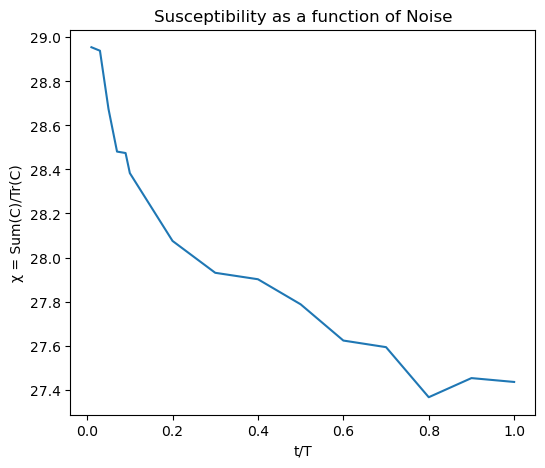

In [671]:
import matplotlib.pyplot as plt

x=[0.01,0.03,0.05,0.07,0.09,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]


plt.figure(figsize=(6,5))
plt.plot(x,result_new)
plt.xlabel('t/T')
plt.ylabel('χ = Sum(C)/Tr(C)')
plt.title("Susceptibility as a function of Noise")
plt.savefig('correlator_vs_time_efp4.png', dpi=300, bbox_inches='tight')
plt.show()
#plt.save()

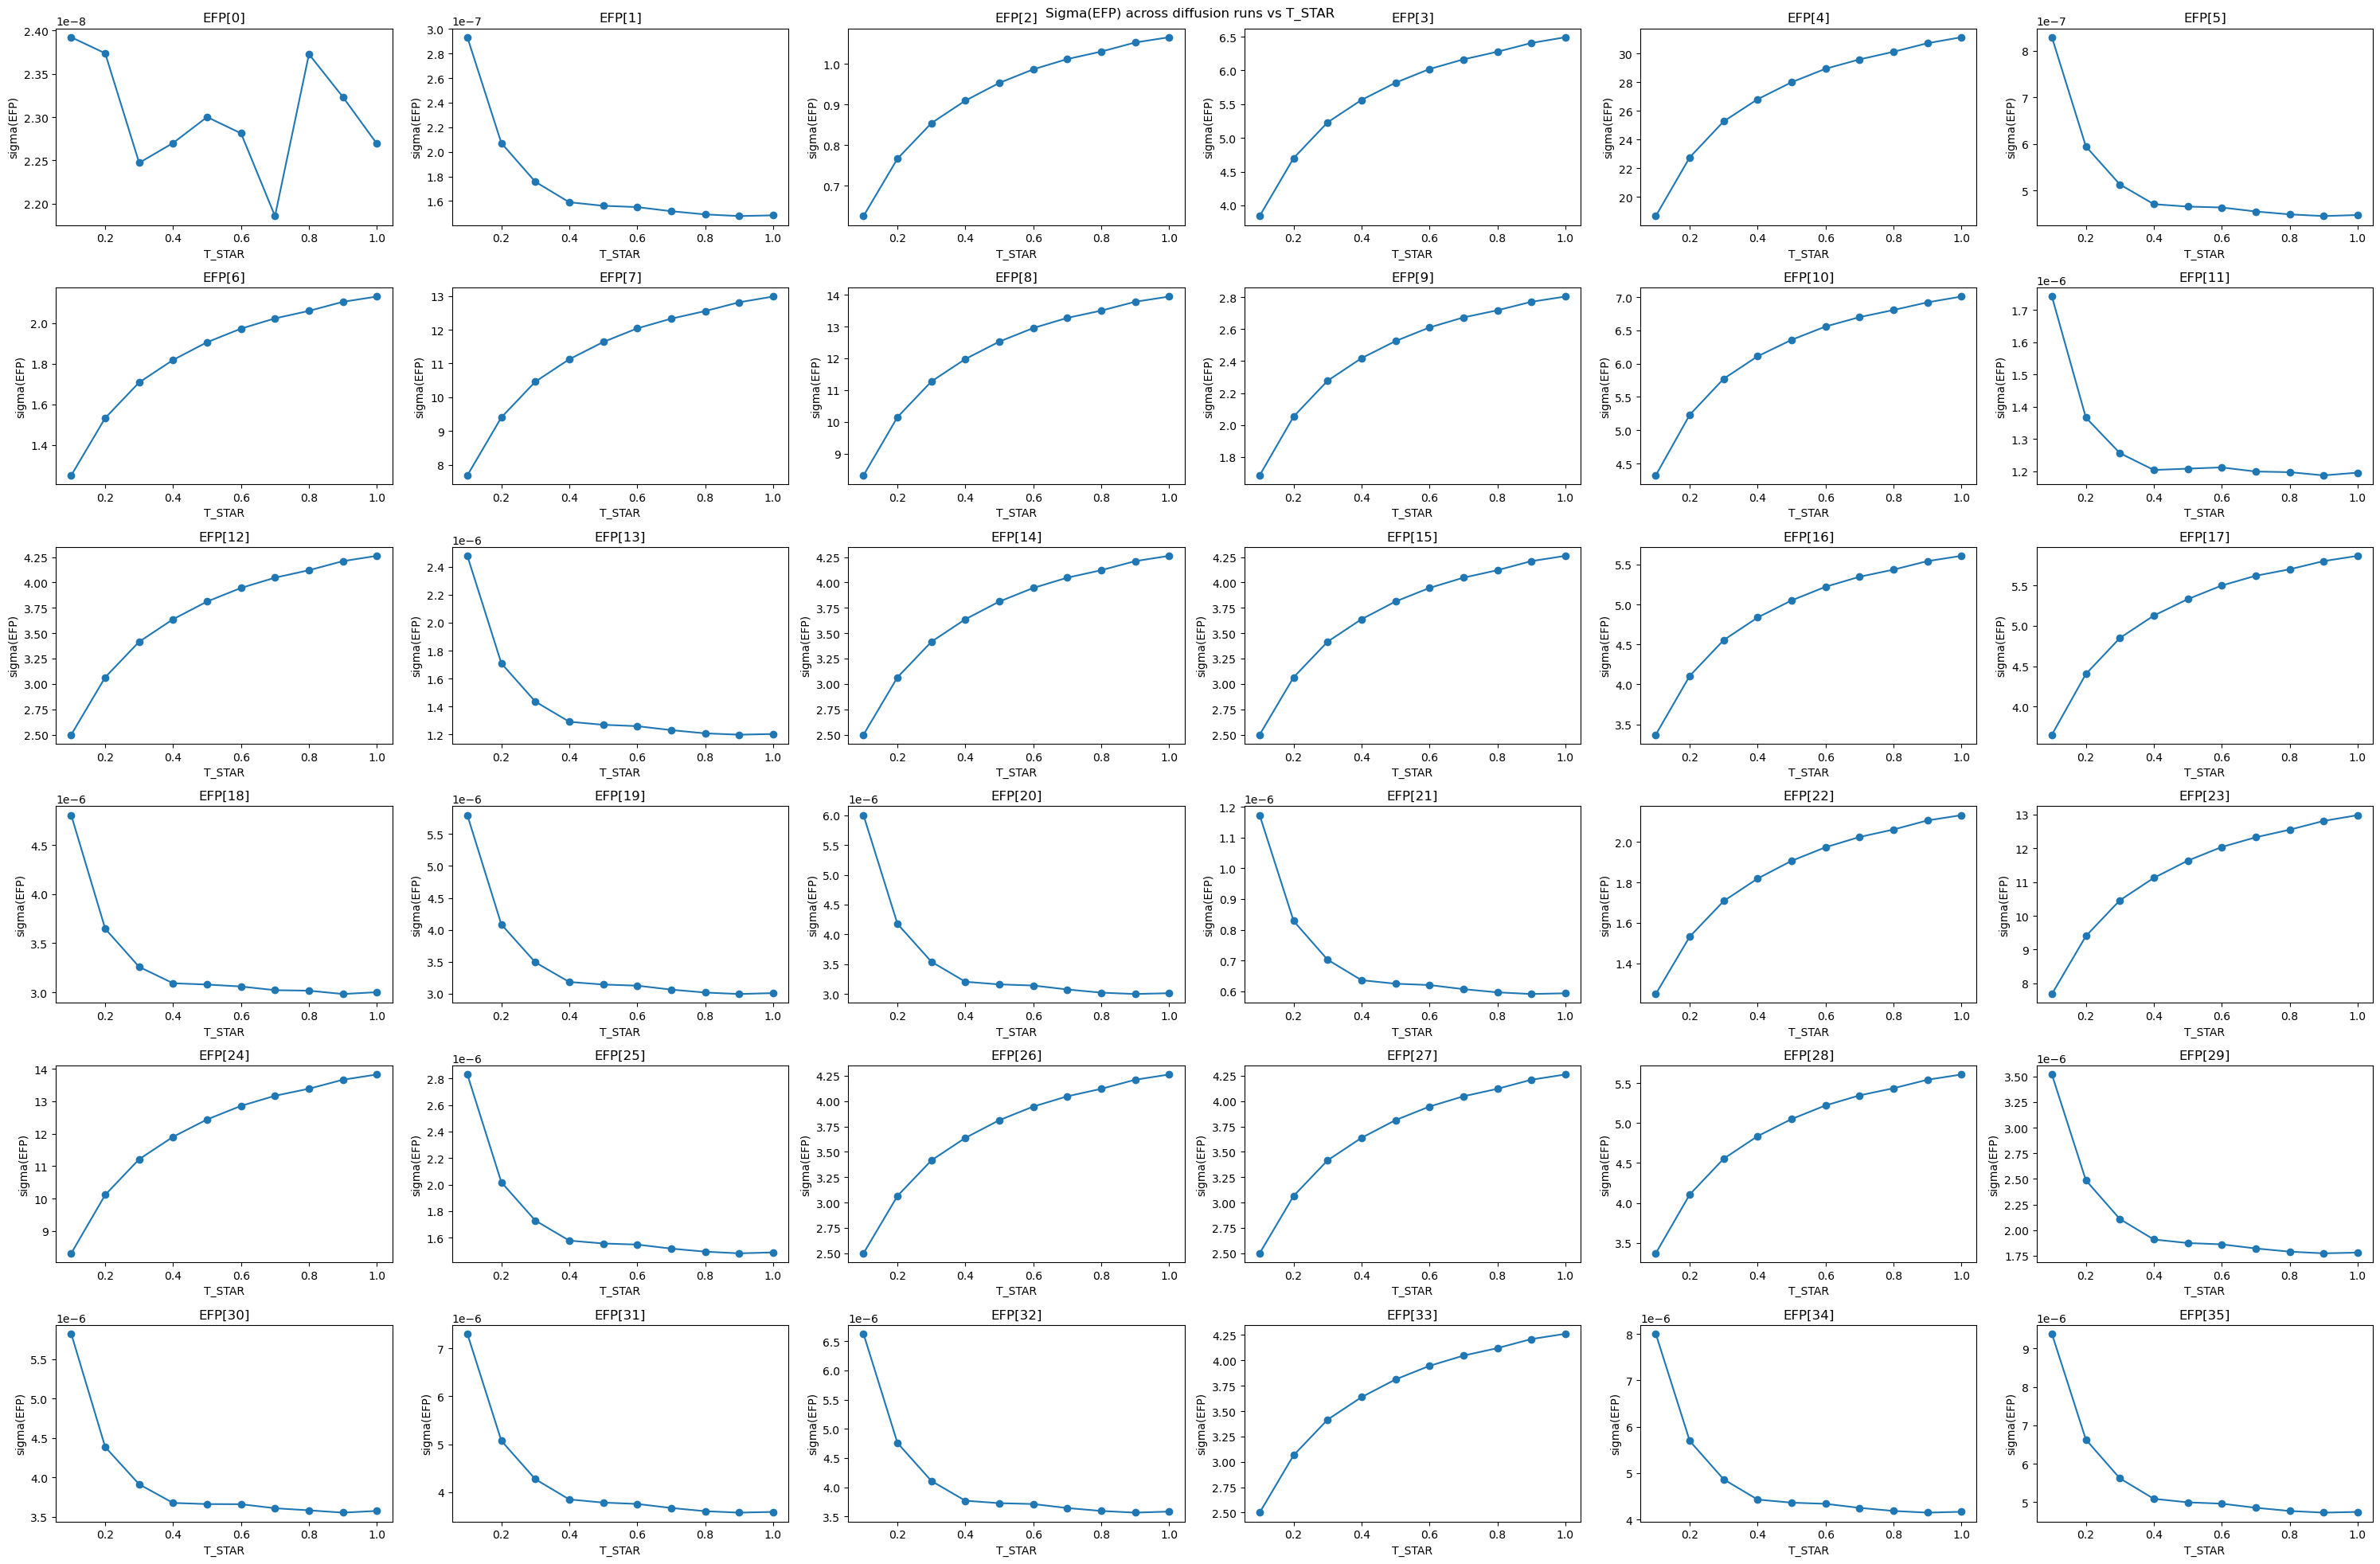

In [257]:
fig, axes = plt.subplots(6, 6, figsize=(30, 20))  # adjust grid to n_efp
axes = axes.flatten()

for efp_idx in range(chi_mean.shape[1]):
    ax = axes[efp_idx]
    ax.plot(x, chi_mean[:, efp_idx], marker='o')
    ax.set_xlabel('T_STAR')
    ax.set_ylabel('sigma(EFP)')
    ax.set_title(f'EFP[{efp_idx}]')

# Hide unused subplots if n_efp < grid size
for idx in range(chi_mean.shape[1], len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Sigma(EFP) across diffusion runs vs T_STAR')
plt.tight_layout()
plt.show()

In [259]:
trend = chi_mean[-1] - chi_mean[0]  # positive = increasing, negative = decreasing
decreasing_efps = np.where(trend < 0)[0]
increasing_efps = np.where(trend > 0)[0]

print('Decreasing EFP indices:', decreasing_efps)
print('Increasing EFP indices:', increasing_efps)

# Check their mean values
print('\nMean values of decreasing EFPs:')
print(np.nanmean(chi_mean[:, decreasing_efps], axis=0))
print('\nMean values of increasing EFPs:')
print(np.nanmean(chi_mean[:, increasing_efps], axis=0))

Decreasing EFP indices: [ 0  1  5 11 13 18 19 20 21 25 29 30 31 32 34 35]
Increasing EFP indices: [ 2  3  4  6  7  8  9 10 12 14 15 16 17 22 23 24 26 27 28 33]

Mean values of decreasing EFPs:
[2.30151612e-08 1.74347679e-07 5.13575813e-07 1.27630576e-06
 1.42769511e-06 3.29669340e-06 3.49079254e-06 3.53230828e-06
 6.97388161e-07 1.72425634e-06 2.09215682e-06 3.94371909e-06
 4.24899989e-06 4.10858908e-06 4.84305506e-06 5.57906442e-06]

Mean values of increasing EFPs:
[ 0.92536724  5.65058254 27.20067698  1.85073435 11.30116448 12.1693529
  2.45341699  6.17961982  3.70146838  3.70146854  3.70146848  4.90683404
  5.18427232  1.85073436 11.30116474 12.08695437  3.70146855  3.70146846
  4.90683412  3.70146848]


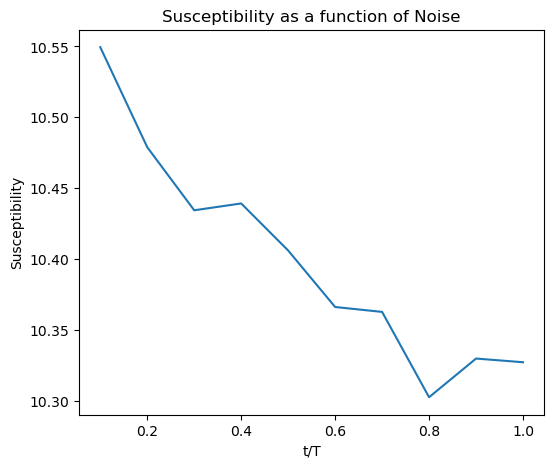

In [265]:
diff_new=diff[:,:,:,increasing_efps]

correlator = np.einsum('...i,...j->...ij', diff_new, diff_new)                                                 # correlator
diff_avg= np.nanmean(diff_new,axis=1)                                                                      # avg over the diffusion trajectories for sigma
correlator_avg = np.nanmean(correlator, axis=1) - np.einsum('...i,...j->...ij', diff_avg, diff_avg)    # connected correlator
corr_final=np.nanmean(correlator_avg,axis=1)    


diag_sum = np.trace(corr_final, axis1=1, axis2=2)        # trace of the correlator
total_sum = corr_final.sum(axis=(1, 2))                  # Correlator sum
result = total_sum / diag_sum                            # Susceptibility

x=np.arange(1,T+1)/T


plt.figure(figsize=(6,5))
plt.plot(x,result)
plt.xlabel('t/T')
plt.ylabel('Susceptibility')
plt.title("Susceptibility as a function of Noise")
plt.savefig('correlator_vs_time_efp5.png', dpi=300, bbox_inches='tight')
plt.show()

In [279]:
print(correlator.shape)

(10, 20, 1000, 20, 20)


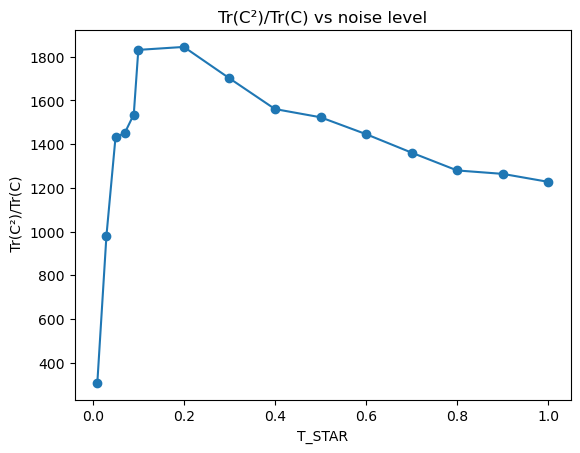

In [677]:
cov_matrix = corr_final#np.nanmean(correlator, axis=(1, 2))  # (10, n_efp, n_efp)

# Compute susceptibility
trace_C  = np.trace(cov_matrix, axis1=-2, axis2=-1)        # (10,)
trace_C2 = np.trace(cov_matrix @ cov_matrix, axis1=-2, axis2=-1)  # (10,)

chi = trace_C2 / (trace_C)   # (10,)

plt.plot(x, chi, marker='o')
plt.xlabel('T_STAR')
plt.ylabel(' Tr(C²)/Tr(C)')
plt.title('Tr(C²)/Tr(C) vs noise level')
plt.savefig('Tr(C²)Tr(C)_vs_time_efp4.png', dpi=300, bbox_inches='tight')
plt.show()

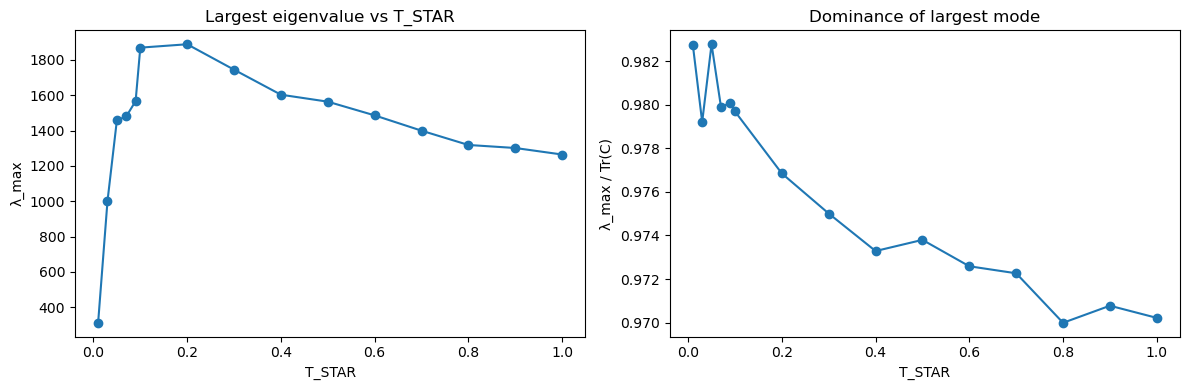

In [709]:
eigenvalues = np.linalg.eigvalsh(cov_matrix)  # (10, n_efp) sorted ascending

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot largest eigenvalue vs T_STAR
axes[0].plot(x, eigenvalues[:, -1], marker='o')
axes[0].set(xlabel='T_STAR', ylabel='λ_max', title='Largest eigenvalue vs T_STAR')

# Plot ratio of largest to sum
ratio = eigenvalues[:, -1] / eigenvalues.sum(axis=1)
axes[1].plot(x, ratio, marker='o')
axes[1].set(xlabel='T_STAR', ylabel='λ_max / Tr(C)', title='Dominance of largest mode')

plt.tight_layout()
plt.show()

102


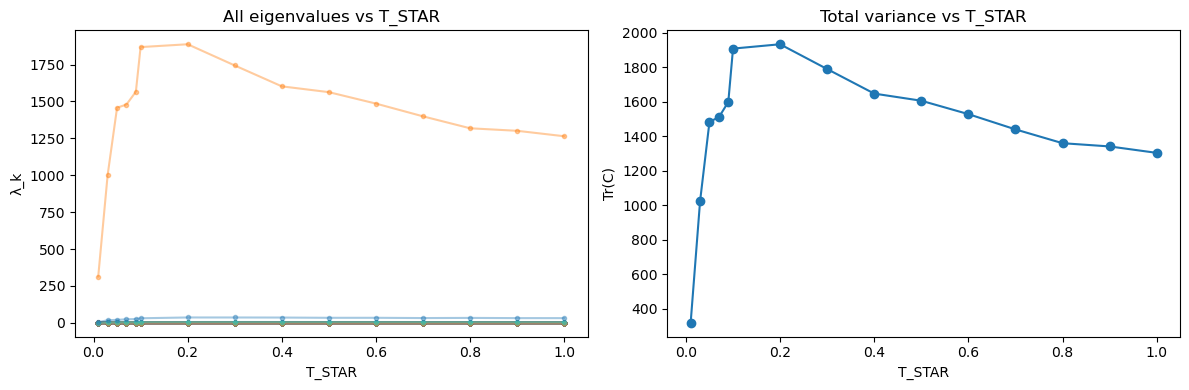

In [711]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

print(eigenvalues.shape[1])
# Plot all eigenvalues vs T_STAR
for k in range(eigenvalues.shape[1]):
    axes[0].plot(x, eigenvalues[:, k], alpha=0.4, marker='o', markersize=3)
axes[0].set(xlabel='T_STAR', ylabel='λ_k', title='All eigenvalues vs T_STAR')

# Plot Tr(C) vs T_STAR
axes[1].plot(x, eigenvalues.sum(axis=1), marker='o')
axes[1].set(xlabel='T_STAR', ylabel='Tr(C)', title='Total variance vs T_STAR')

plt.savefig('eigenvalues vs noise for efp.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

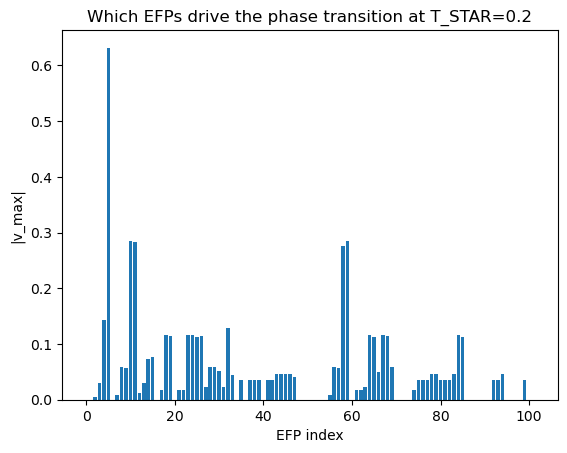

In [699]:
peak_idx = np.argmin(np.abs(np.array(x) - 0.2))
_, eigenvectors = np.linalg.eigh(cov_matrix[peak_idx])

v_max = eigenvectors[:, -1]  # dominant eigenvector

plt.bar(range(len(v_max)), np.abs(v_max))
plt.xlabel('EFP index')
plt.ylabel('|v_max|')
plt.title('Which EFPs drive the phase transition at T_STAR=0.2')
plt.show()

In [665]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(results)
v_pca1 = pca.components_[0]  # top PCA direction

# Cosine similarity with your order parameter
cosine = np.abs(np.dot(v_max, v_pca1))
print(f'Cosine similarity between v_max and top PCA direction: {cosine:.4f}')

# Project out the PCA component from v_max
v_pca1 = pca.components_[0]
v_parallel     = np.dot(v_max, v_pca1) * v_pca1   # component along PCA1
v_perpendicular = v_max - v_parallel                # orthogonal remainder

print('Parallel magnitude:     ', np.linalg.norm(v_parallel))
print('Perpendicular magnitude:', np.linalg.norm(v_perpendicular))

# Which EFPs are in the perpendicular component?
top_perp = np.argsort(np.abs(v_perpendicular))[::-1][:5]
print('Top EFPs in perpendicular component:', top_perp)
#print('Their degrees:', [degrees[i] for i in top_perp])

for k in range(5):
    cosine_k = np.abs(np.dot(v_max, pca.components_[k]))
    var_explained = pca.explained_variance_ratio_[k]
    print(f'PCA component {k+1}: cosine={cosine_k:.4f}  '
          f'variance explained={var_explained:.4f}')
#peak_idx = np.argmin(np.abs(np.array(x) - 0.2))
#_, eigenvectors = np.linalg.eigh(cov_matrix[peak_idx])
#v_max = eigenvectors[:, -1]

#print('Sum of v_max components:', v_max.sum())
#print('Positive components:', (v_max > 0).sum())
#print('Negative components:', (v_max < 0).sum())

Cosine similarity between v_max and top PCA direction: 0.8826
Parallel magnitude:      0.8825870427771914
Perpendicular magnitude: 0.470149031607865
Top EFPs in perpendicular component: [14 15 66 30 69]
PCA component 1: cosine=0.8826  variance explained=0.9977
PCA component 2: cosine=0.1197  variance explained=0.0017
PCA component 3: cosine=0.2035  variance explained=0.0004
PCA component 4: cosine=0.2595  variance explained=0.0001
PCA component 5: cosine=0.1844  variance explained=0.0000


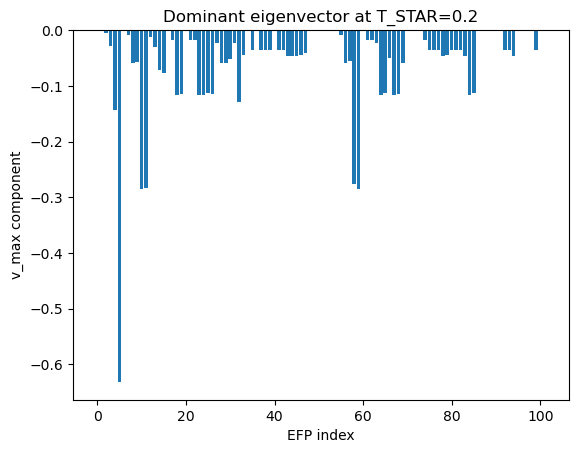

AttributeError: 'list' object has no attribute 'edges'

In [611]:

plt.bar(range(len(v_max)), v_max)
plt.xlabel('EFP index')
plt.ylabel('v_max component')
plt.title('Dominant eigenvector at T_STAR=0.2')
plt.show()

# Cross reference with EFP degrees
graphs = efpset.graphs()   # get the EFP graph structures
degrees = [len(g.edges()) for g in graphs]  # degree of each EFP

# Plot sorted by degree
plt.scatter(degrees, np.abs(v_max))
plt.xlabel('EFP degree')
plt.ylabel('|v_max|')
plt.title('Eigenvector weight vs EFP degree')
plt.show()

In [455]:
ind = 7
graph = efpset.graphs(ind)
n, _, d, v, _, c, p, _ = efpset.specs[ind]

print("Graph:", graph)
print("Number of vertices, n:", n)
print("Number of edges,    d:", d)
print("Maximum valency,    v:", v)
print("VE complexity,      c:", c)
print("Number of primes,   p:", p)

Graph: [(0, 1), (0, 2), (0, 2), (0, 2)]
Number of vertices, n: 3
Number of edges,    d: 4
Maximum valency,    v: 4
VE complexity,      c: 2
Number of primes,   p: 1


In [457]:
v_max_all = np.zeros((len(x), cov_matrix.shape[-1]))

for i in range(len(x)):
    eigenvalues_full, eigenvectors = np.linalg.eigh(cov_matrix[i])
    v_max_all[i] = eigenvectors[:, -1]  # dominant eigenvector at each T_STAR

print('v_max_all shape:', v_max_all.shape)  # (len(T_STARS), n_efp)

v_max_all shape: (15, 36)


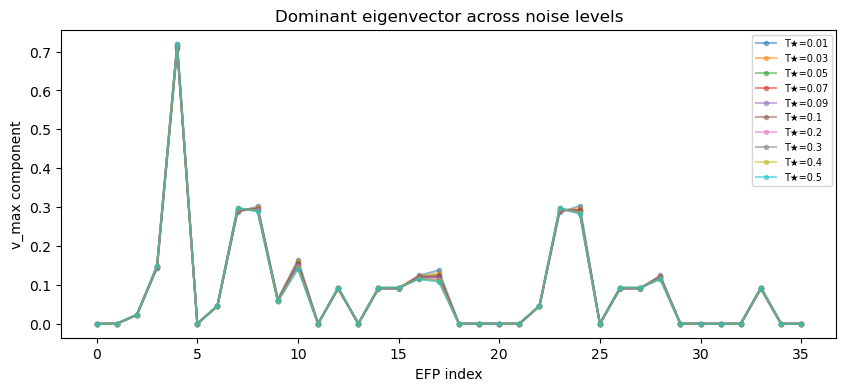

In [539]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, T_STAR in enumerate(x[:10]):
    ax.plot(range(len(v_max_all[i])), np.abs(v_max_all[i]), 
            alpha=0.5, marker='o', markersize=3, label=f'T★={T_STAR}')
ax.set_xlabel('EFP index')
ax.set_ylabel('v_max component')
ax.legend(fontsize=7)
plt.title('Dominant eigenvector across noise levels')
plt.savefig('Dominant_eigenvector_efp4')
plt.show()


T_STAR= 0.010  cosine with peak: 0.8826
T_STAR= 0.030  cosine with peak: 0.8858
T_STAR= 0.050  cosine with peak: 0.8881
T_STAR= 0.070  cosine with peak: 0.8900
T_STAR= 0.090  cosine with peak: 0.8916
T_STAR= 0.100  cosine with peak: 0.8909
T_STAR= 0.200  cosine with peak: 0.8940
T_STAR= 0.300  cosine with peak: 0.8958
T_STAR= 0.400  cosine with peak: 0.8973
T_STAR= 0.500  cosine with peak: 0.8982
T_STAR= 0.600  cosine with peak: 0.8996
T_STAR= 0.700  cosine with peak: 0.9001
T_STAR= 0.800  cosine with peak: 0.9011
T_STAR= 0.900  cosine with peak: 0.9014
T_STAR= 1.000  cosine with peak: 0.9020


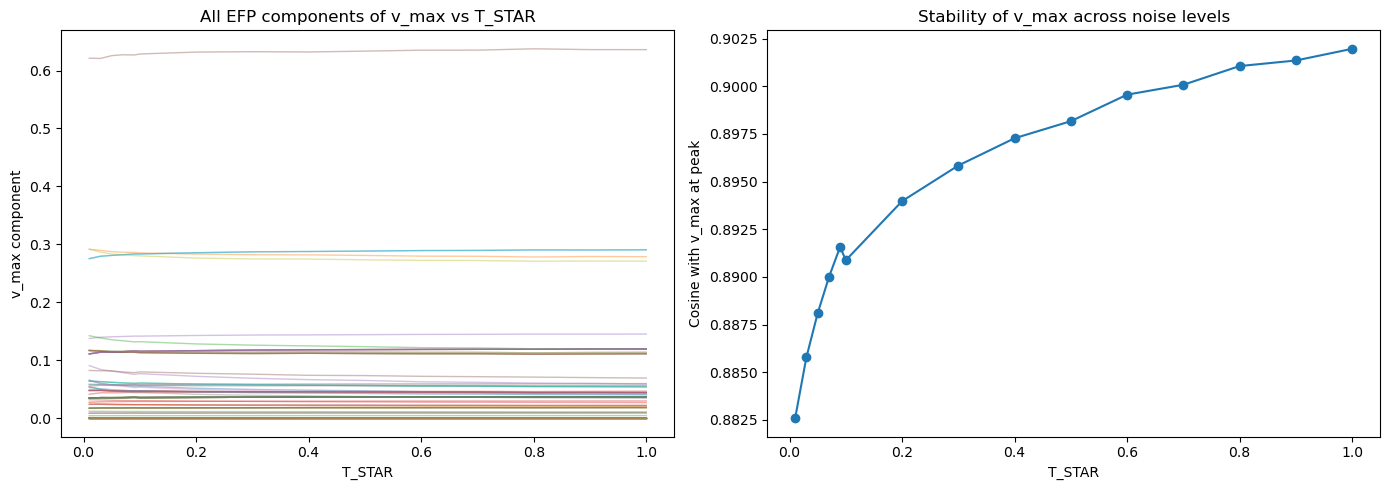

In [613]:
# Compute v_max at each T_STAR level with sign fixing
T_STARS=x.copy()
v_max_all = np.zeros((len(T_STARS), cov_matrix.shape[-1]))

for i in range(len(T_STARS)):
    _, evecs = np.linalg.eigh(cov_matrix[i])
    v = evecs[:, -1]
    v = v * np.sign(v[np.argmax(np.abs(v))])  # fix sign
    v_max_all[i] = v

# Plot components of v_max vs T_STAR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot each EFP component as a line vs T_STAR
for efp_idx in range(v_max_all.shape[1]):
    axes[0].plot(T_STARS, v_max_all[:, efp_idx], alpha=0.4, lw=1)
axes[0].set(xlabel='T_STAR', ylabel='v_max component', 
            title='All EFP components of v_max vs T_STAR')

# Plot cosine similarity with v_max at peak
for i in range(len(T_STARS)):
    cosine = np.abs(np.dot(v_max_all[i], v_pca1))
    print(f'T_STAR={T_STARS[i]:6.3f}  cosine with peak: {cosine:.4f}')

axes[1].plot(T_STARS, 
             [np.abs(np.dot(v_max_all[i], v_pca1)) 
              for i in range(len(T_STARS))], 
             marker='o')
axes[1].set(xlabel='T_STAR', ylabel='Cosine with v_max at peak', 
            title='Stability of v_max across noise levels')

plt.tight_layout()
plt.show()

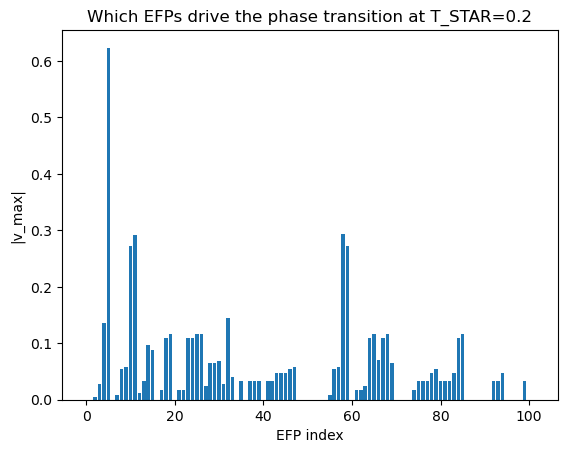

In [631]:
plt.bar(range(len(v_pca1)), np.abs(v_pca1))
plt.xlabel('EFP index')
plt.ylabel('|v_max|')
plt.title('Which EFPs drive the phase transition at T_STAR=0.2')
plt.show()

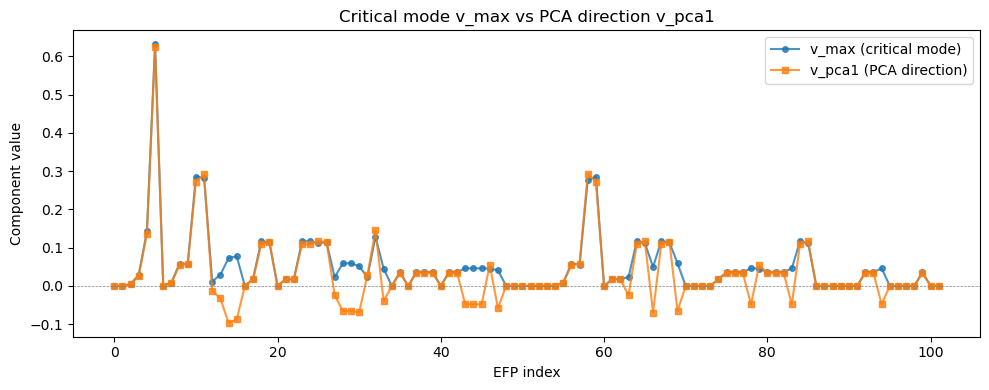

In [643]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(v_max))

ax.plot(x, -v_max, marker='o', markersize=4, label='v_max (critical mode)', alpha=0.8)
ax.plot(x, v_pca1, marker='s', markersize=4, label='v_pca1 (PCA direction)', alpha=0.8)

ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('EFP index')
ax.set_ylabel('Component value')
ax.set_title('Critical mode v_max vs PCA direction v_pca1')
ax.legend()

plt.tight_layout()
plt.show()

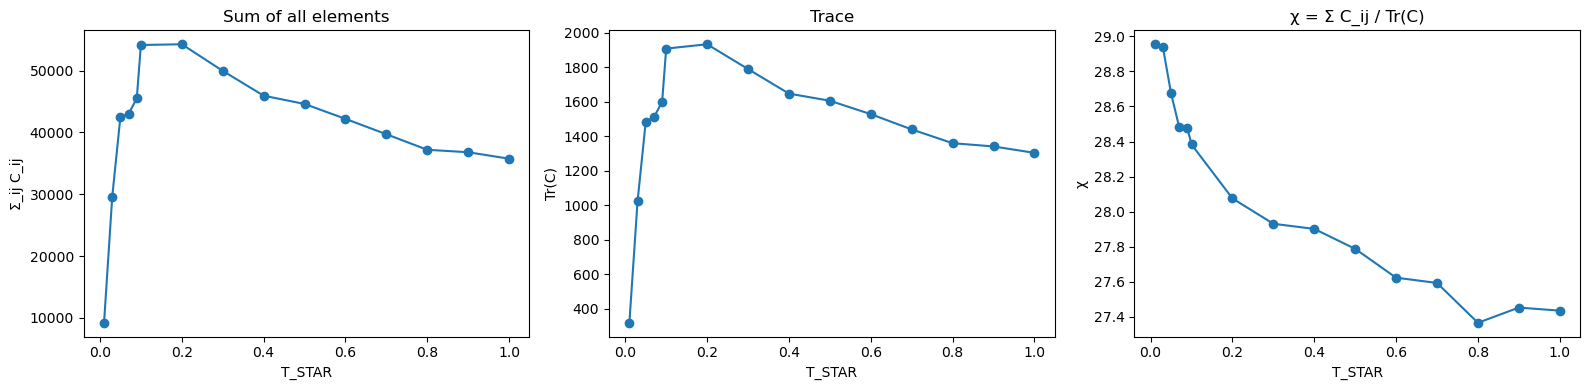

In [701]:
T_STARS=x

sum_all  = np.array([cov_matrix[i].sum() for i in range(len(T_STARS))])
trace_C  = np.array([np.trace(cov_matrix[i]) for i in range(len(T_STARS))])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(T_STARS, sum_all, marker='o')
axes[0].set(xlabel='T_STAR', ylabel='Σ_ij C_ij', title='Sum of all elements')

axes[1].plot(T_STARS, trace_C, marker='o')
axes[1].set(xlabel='T_STAR', ylabel='Tr(C)', title='Trace')

axes[2].plot(T_STARS, sum_all / trace_C, marker='o')
axes[2].set(xlabel='T_STAR', ylabel='χ', title='χ = Σ C_ij / Tr(C)')

plt.tight_layout()
plt.show()

In [703]:
print(f'(Σ v_i)² / ||v||²  = {v_max.sum()**2 / np.dot(v_max, v_max):.4f}')
print(f'Observed chi range: {sum_all/trace_C}')


(Σ v_i)² / ||v||²  = 28.4499
Observed chi range: [28.95522796 28.93929454 28.67484484 28.48113247 28.47460288 28.38335588
 28.07529426 27.93056547 27.90129731 27.78742205 27.62282664 27.592855
 27.36539456 27.45228119 27.43474296]
